# CAB420, Practical 1 - Question 1 Template
## Linear Regression

Using the dataset from Problem 1, split the data into training, validation and testing as follows:
* Training: All data from the years 2014-2016
* Validation: All data from 2017
* Training: All data from 2018

Develop a regression model to predict one of the cycleway data series in your dataset. In developing this model you should:
* Initially, use all weather data (temperature, rainfall and solar exposure) and all other data series for a particular counter type (i.e. if you’re predicting cyclists inbound for a counter, use all other cyclist inbound counters)
* Use p-values, qqplots, and performance on the validation set to remove terms and improve the model.

When you have finished refining the model, evaluate it on test set, and compare the Root Mean Squared Error (RMSE) for the training, validation and test sets.

In training the model, you will need to ensure that you have no samples (i.e. rows) with missing data. As such, you should remove samples with missing data from the dataset before training and evaluating the model. This may also mean that you have to remove some columns that contain large amounts of missing data.

### Relevant Examples

The first linear regression example, ``CAB420_Regression_Example_1_Linear_Regression.ipynb`` is a useful starting point here.

### Suggested Packages

The following packages are suggested, however there are many ways to approach things in python, if you'd rather use different pacakges that's cool too.

In [1]:
# numpy handles pretty much anything that is a number/vector/matrix/array
import numpy as np
# pandas handles dataframes
import pandas as pd
# matplotlib emulates Matlabs plotting functionality
import matplotlib.pyplot as plt
# seaborn is another good plotting library. In particular, I like it for heatmaps (https://seaborn.pydata.org/generated/seaborn.heatmap.html)
import seaborn as sns;
# stats models is a package that is going to perform the regression analysis
from statsmodels import api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error
# os allows us to manipulate variables on out local machine, such as paths and environment variables
import os
# self explainatory, dates and times
from datetime import datetime, date
# a helper package to help us iterate over objects
import itertools

### Step 1: Load the data
This may be the data you created in Q1, or the pre-baked merged data.

Use pandas and the read_csv function to load the data. It is suggested you inspect the data after loading (print some of it, use the ``head()`` function, possibly plot some series) as a sanity check.

In [2]:
combined = pd.read_csv('combined.csv')
combined['Date'] = pd.to_datetime(combined['Date'], format='mixed', dayfirst=True)
combined.head()

,Unnamed: 0,Rainfall amount (millimetres),Date,Maximum temperature (Degree C),Daily global solar exposure (MJ/m*m),North Brisbane Bikeway Mann Park Windsor Cyclists Outbound,Jack Pesch Bridge Pedestrians Outbound,Story Bridge East Pedestrian Inbound,Kedron Brook Bikeway Lutwyche Pedestrians Outbound,Kedron Brook Bikeway Mitchelton Pedestrian Outbound,...,Story Bridge East Pedestrian Outbound,North Brisbane Bikeway Mann Park Windsor Pedestrian Outbound,Story Bridge West Cyclists Inbound,Bicenntenial Bikeway,Story Bridge East Cyclists Inbound,Bishop Street Pedestrians Inbound,Story Bridge West Cyclists Outbound,North Brisbane Bikeway Mann Park Windsor Pedestrian Inbound,Kedron Brook Bikeway Mitchelton Pedestrian Inbound,Schulz Canal Bridge Cyclists Inbound
0,0,0.0,2014-01-01,30.6,31.2,NaN,NaN,0.0,NaN,NaN,...,0.0,NaN,0.0,3333.0,0.0,NaN,0.0,NaN,NaN,92.0
1,1,0.0,2014-01-02,31.8,23.4,NaN,NaN,0.0,NaN,NaN,...,0.0,NaN,0.0,4863.0,0.0,NaN,0.0,NaN,NaN,123.0
2,2,1.0,2014-01-03,34.5,29.6,NaN,NaN,0.0,NaN,NaN,...,0.0,NaN,0.0,3905.0,0.0,NaN,0.0,NaN,NaN,77.0
3,3,0.0,2014-01-04,38.7,30.5,NaN,NaN,0.0,NaN,NaN,...,0.0,NaN,0.0,3066.0,0.0,NaN,0.0,NaN,NaN,57.0
4,4,0.0,2014-01-05,33.6,15.7,NaN,NaN,0.0,NaN,NaN,...,0.0,NaN,0.0,4550.0,0.0,NaN,0.0,NaN,NaN,92.0


### Step 2: Filter the data

As you inspect the data, you may see some series have fewer samples than others. Trying to find rows that have all data series may lead to having too little data for analysis. A suggested approach is:
* Remove columns that have too many missin values. Use the ``dropna()`` function while setting ``axis=1`` and a threshold, such that only columns with threshold valid values or more are retained (a suggested value for threshold is about 1500, i.e. if any more than about 300 values are missing, the column should be removed).
* Now, remove the other rows that have missing values. Here, you could use ``dropna()`` operating over the rows (i.e. ``axis=0``).

In [3]:
combined.shape
# we have 1826 rows and 57 columns
# we need to remove rows with lots of na values, first determine the threshold based on the number of rows
threshold = combined.shape[0] - 300
combined_filtered = combined.dropna(axis=1, thresh=threshold)
print(combined_filtered.shape)
combined_filtered = combined_filtered.dropna(axis = 0)
print(combined_filtered.shape)
combined_filtered.head()

(1826, 25)
(1422, 25)


,Unnamed: 0,Rainfall amount (millimetres),Date,Maximum temperature (Degree C),Daily global solar exposure (MJ/m*m),Story Bridge East Pedestrian Inbound,Schulz Canal Bridge Cyclists Outbound,Story Bridge West Pedestrian Outbound,Bicentennial Bikeway Pedestrians Inbound,Story Bridge West Pedestrian Inbound,...,Bicentennial Bikeway Pedestrians Outbound,Story Bridge East Cyclists Outbound,Bicentennial Bikeway Cyclists Outbound,Story Bridge East Pedestrian Outbound,North Brisbane Bikeway Mann Park Windsor Pedestrian Outbound,Story Bridge West Cyclists Inbound,Bicenntenial Bikeway,Story Bridge East Cyclists Inbound,North Brisbane Bikeway Mann Park Windsor Pedestrian Inbound,Schulz Canal Bridge Cyclists Inbound
169,169,0.0,2014-06-19,20.3,8.0,0.0,55.0,0.0,1630.0,0.0,...,1900.0,0.0,333.0,0.0,0.0,0.0,4223.0,0.0,0.0,60.0
170,170,5.8,2014-06-20,22.5,9.1,0.0,49.0,0.0,1170.0,0.0,...,1586.0,0.0,403.0,0.0,0.0,0.0,3619.0,0.0,0.0,45.0
171,171,0.0,2014-06-21,25.6,12.9,0.0,67.0,0.0,1289.0,0.0,...,1847.0,0.0,642.0,0.0,0.0,0.0,4423.0,0.0,0.0,72.0
172,172,5.2,2014-06-22,24.2,13.0,0.0,76.0,0.0,1542.0,0.0,...,2126.0,0.0,635.0,0.0,0.0,0.0,5023.0,0.0,0.0,82.0
173,173,0.2,2014-06-23,24.1,13.6,0.0,69.0,0.0,1862.0,0.0,...,2180.0,0.0,631.0,0.0,0.0,0.0,5329.0,0.0,0.0,74.0


### Step 3: Split into Train, Validation and Test Splits

You can split the data now. Be sure to check dataset size after splitting to make sure that you have datasets of roughly the size you expect.

As part of this you should also pull out your X and Y data, i.e. your predictors and response.

You could also visualise some of this data, and aspects such as:
* Correlation between predictors and the response
* Correlation between pairs of predictors

In [4]:
train = combined_filtered[combined_filtered.Date < datetime(year=2017, month=1, day=1)]
val = combined_filtered[((combined_filtered.Date >= datetime(year=2017, month=1, day=1)) &
                        (combined_filtered.Date < datetime(year=2018, month=1, day=1)))]
test = combined_filtered[((combined_filtered.Date >= datetime(year=2018, month=1, day=1)) &
                          (combined_filtered.Date < datetime(year=2019, month=1, day=1)))]
print('num train = {}'.format(train.shape[0]))
print('val train = {}'.format(val.shape[0]))
print('test train = {}'.format(test.shape[0]))

## I want to see the data as a csv
training_data = pd.DataFrame(train)
training_data.to_csv('training_data.csv')

num train = 888
val train = 276
test train = 258


### Step 4: Create the Model

Using the X and Y arrays you created above, fit a regression model. 

Explore the outputs you get from the model, including:
* The resultant model, including coefficients, p-values, and $R^2$
* A QQ-Plot, to see if assumptions around residuals hold

Model 1 RMSE = 623.3791739360696
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.474
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     113.1
Date:                Thu, 05 Mar 2026   Prob (F-statistic):          4.59e-118
Time:                        15:18:50   Log-Likelihood:                -6899.6
No. Observations:                 888   AIC:                         1.382e+04
Df Residuals:                     880   BIC:                         1.385e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        739.22

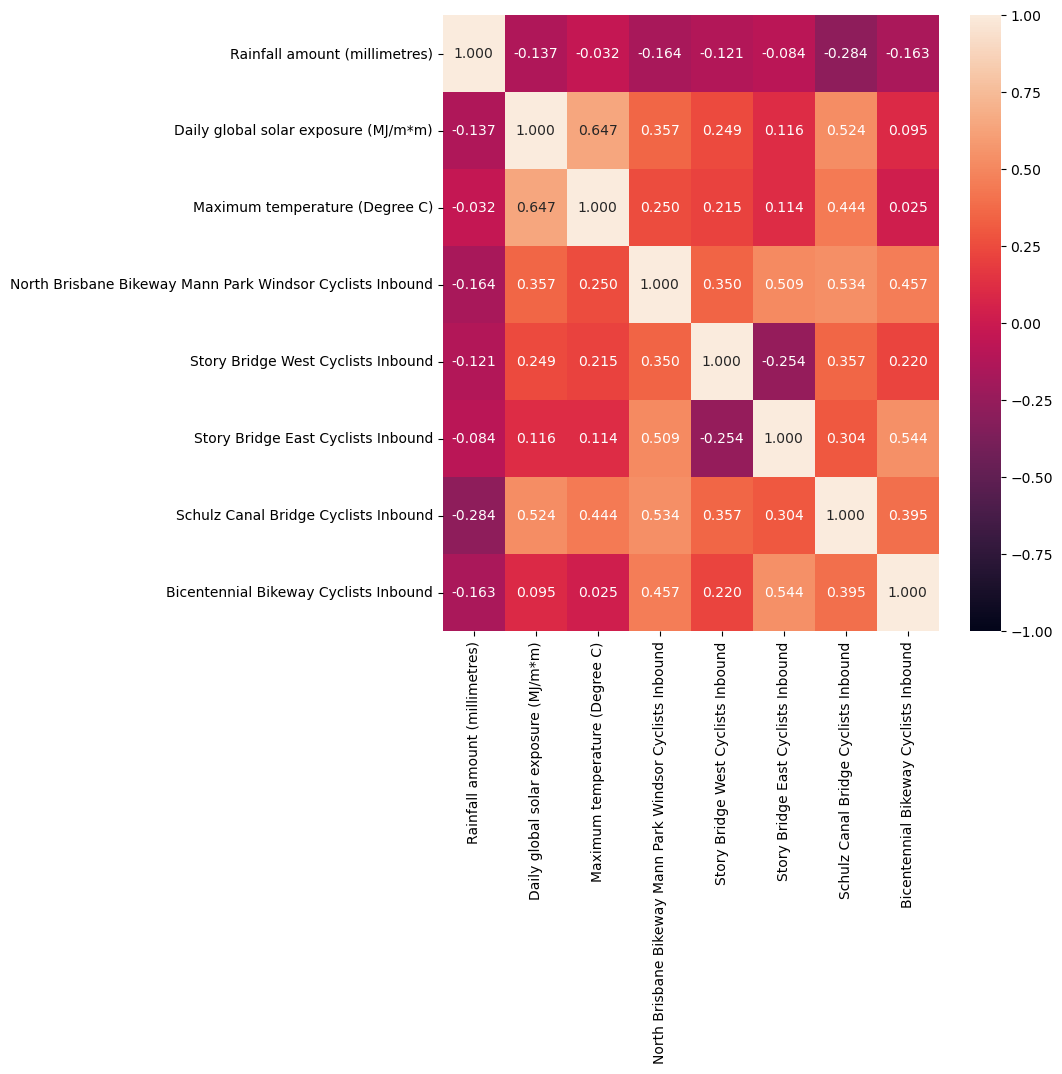

In [7]:
X_bom = ['Rainfall amount (millimetres)',
         'Daily global solar exposure (MJ/m*m)',
         'Maximum temperature (Degree C)']

# finding columns with cyclist inbound and appending it to X_bom
x_bbc = [x for x in train.columns.values if "Cyclists Inbound" in x]


#we are setting our response variable as BicentennialBikewayCyclistsInbound so we need to remove it from x_bbc
x_bbc.remove("Bicentennial Bikeway Cyclists Inbound")

X_variables = X_bom + x_bbc

Y_variable = 'Bicentennial Bikeway Cyclists Inbound'
Y_train = np.array(train[Y_variable], dtype=np.float64)
X_train = np.array(train[X_variables], dtype=np.float64)
X_train = sm.add_constant(X_train) # adding a column of all 1 to represent the y int

# repeating the exact same thing for our other data sets
Y_val = np.array(val[Y_variable], dtype=np.float64)
X_val = np.array(val[X_variables], dtype=np.float64)
X_val = sm.add_constant(X_val)

Y_test = np.array(test[Y_variable], dtype=np.float64)
X_test = np.array(test[X_variables], dtype=np.float64)
X_test = sm.add_constant(X_test)

all_variables = X_variables + ['Bicentennial Bikeway Cyclists Inbound']

#from our training data set, take all of the varibales (response + predictors) and create a correlation map
corr_coeffs = train[all_variables].corr()
# plotting this correlation map
fig, ax = plt.subplots(figsize=(8,8))
ax = sns.heatmap(corr_coeffs, annot=True, fmt="1.3f", vmin=-1.0, vmax=1.0)

## Now we create the model 
model = sm.OLS(Y_train, X_train)
#learning the model
model_1 = model.fit()
# using the model to predict on the validation data
prediction_1 = model_1.predict(X_val)
print('Model 1 RMSE = {}'.format(
  np.sqrt(mean_squared_error(Y_val, model_1.predict(X_val)))))
print(model_1.summary())


[ 7.39227580e+02 -2.12180551e+00 -5.90348877e+00 -3.40164060e+01
 -4.87249158e-01  1.18469111e+00  1.94071221e+00  6.23180686e+00]


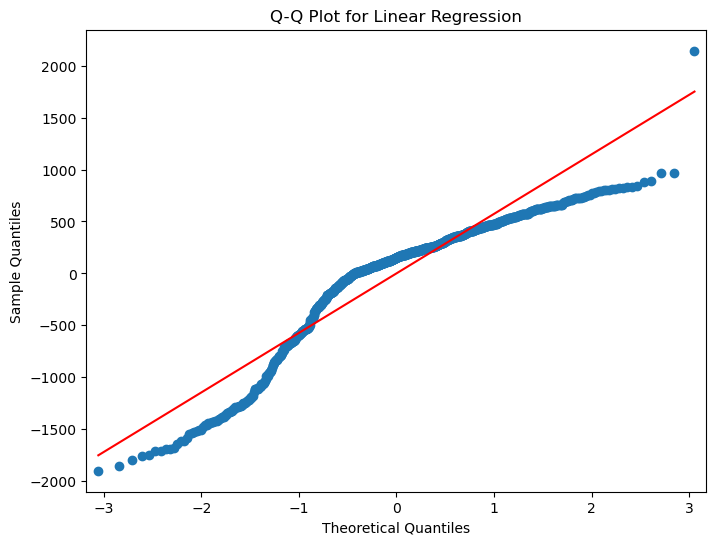

Variables to remove -> Daily global solar exposure (MJ/m*m)


,Unnamed: 0,Date,Maximum temperature (Degree C),Daily global solar exposure (MJ/m*m),Story Bridge East Pedestrian Inbound,Schulz Canal Bridge Cyclists Outbound,Story Bridge West Pedestrian Outbound,Bicentennial Bikeway Pedestrians Inbound,Story Bridge West Pedestrian Inbound,Unnamed: 1,...,Bicentennial Bikeway Pedestrians Outbound,Story Bridge East Cyclists Outbound,Bicentennial Bikeway Cyclists Outbound,Story Bridge East Pedestrian Outbound,North Brisbane Bikeway Mann Park Windsor Pedestrian Outbound,Story Bridge West Cyclists Inbound,Bicenntenial Bikeway,Story Bridge East Cyclists Inbound,North Brisbane Bikeway Mann Park Windsor Pedestrian Inbound,Schulz Canal Bridge Cyclists Inbound
169,169,2014-06-19,20.3,8.0,0.0,55.0,0.0,1630.0,0.0,0:00,...,1900.0,0.0,333.0,0.0,0.0,0.0,4223.0,0.0,0.0,60.0
170,170,2014-06-20,22.5,9.1,0.0,49.0,0.0,1170.0,0.0,0:00,...,1586.0,0.0,403.0,0.0,0.0,0.0,3619.0,0.0,0.0,45.0
171,171,2014-06-21,25.6,12.9,0.0,67.0,0.0,1289.0,0.0,0:00,...,1847.0,0.0,642.0,0.0,0.0,0.0,4423.0,0.0,0.0,72.0
172,172,2014-06-22,24.2,13.0,0.0,76.0,0.0,1542.0,0.0,0:00,...,2126.0,0.0,635.0,0.0,0.0,0.0,5023.0,0.0,0.0,82.0
173,173,2014-06-23,24.1,13.6,0.0,69.0,0.0,1862.0,0.0,0:00,...,2180.0,0.0,631.0,0.0,0.0,0.0,5329.0,0.0,0.0,74.0


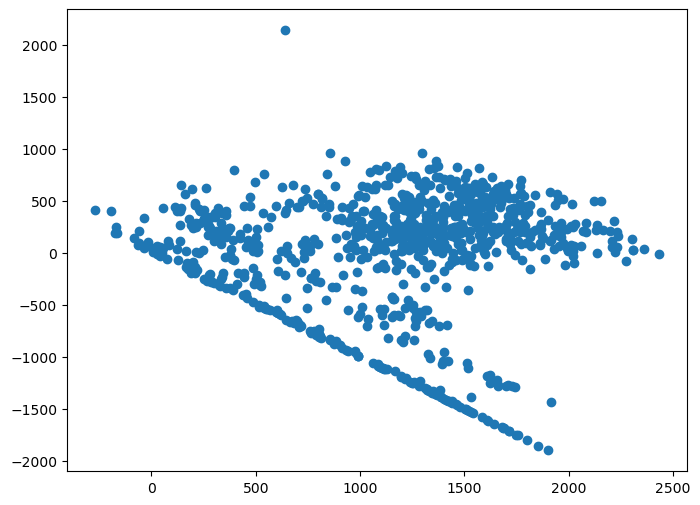

In [17]:
print(model_1.params)
#plot a residuals plot 
fig, ax = plt.subplots(figsize=(8,6))
sm.qqplot(model_1.resid, ax=ax, line='s')
plt.title('Q-Q Plot for Linear Regression')
plt.show()

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(model_1.predict(X_train), model_1.resid)

# dropping models that do not have high pearson correlation factor 
to_remove = [X_variables[0]]
print('Variables to remove -> {}'.format(to_remove[0]))
train = train.drop('Rainfall amount (millimetres)', axis = 1)
# also want to remove these variable names from the X_variable list
X_variables.remove(to_remove[0])
train.head()



In [26]:
#train the model with the dropped factor
#lets create a new x train array

X_train = np.array(train[X_variables], dtype=np.float64) 
#Again we have a add a constant to the model ie the y intercept
X_train = sm.add_constant(X_train)
# do the same for a test and validation set
Y_val = np.array(val[Y_variable], dtype = np.float64)
X_val = np.array(val[X_variables], dtype = np.float64)
X_val = sm.add_constant(X_val)

Y_test = np.array(test[Y_variable], dtype = np.float64)
X_test = np.array(test[X_variables], dtype = np.float64)
X_test = sm.add_constant(X_test)


In [32]:
# Now we make the model and train and test it
model_2 = sm.OLS(Y_train, X_train)
#Fitting the model without any regurilisation
model_2_fit = model_2.fit()
prediction = model_2_fit.predict(X_val)
print('Model 1 RMSE = {}'.format(
  np.sqrt(mean_squared_error(Y_val, model_2_fit.predict(X_val)))))
print(model_2_fit.summary())
print(model_2_fit.params)

Model 1 RMSE = 617.229108721075
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.472
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     157.4
Date:                Thu, 05 Mar 2026   Prob (F-statistic):          1.50e-119
Time:                        15:41:45   Log-Likelihood:                -6901.3
No. Observations:                 888   AIC:                         1.381e+04
Df Residuals:                     882   BIC:                         1.384e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        792.430

### Step 5: Refine the Model, and Evaluate the results

Based on model outputs and other data such as correlation, try to improve the model.

Remove terms that look unhelpful. After a term is removed, evaluate the model on the validation and testing sets.

In [44]:
# looking at p value x1 is non significant so we remove it, lets also remove x2
to_remove = X_variables[0:2] 
print(to_remove)

train = train.drop(to_remove, axis =1)

['Maximum temperature (Degree C)', 'North Brisbane Bikeway Mann Park Windsor Cyclists Inbound']


KeyError: "['Maximum temperature (Degree C)', 'North Brisbane Bikeway Mann Park Windsor Cyclists Inbound'] not found in axis"